# BIND 3D: Flow Matching vs Stochastic Interpolant — Comprehensive Analysis

Compares 3D FM and SI models on held-out test simulations.

**Tests:**
1. Mass conservation — emulated vs truth per volume
2. 3D Power spectrum — individual halo volumes and catalog mean field
3. 3D Radial profiles — from halo center to box edge
4. In-distribution check — voxel distributions, mass function, scaling relations
5. Parameter sensitivity — field-level response to cosmological parameter variation

**Channels:** `DM_hydro` (0), `Gas` (1), `Stars` (2)
**Volume:** configurable via `CROP_SIZE` (default below: 128^3)
**FM inference:** standard `model.fm.sample(...)` (no prior-temperature tuning)


In [1]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from data_3d import load_file_list_3d, AstroDataset3D, NormStats3D
from train_3d import FlowMatchingLit3D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
print(f'Device: {device}')

CHANNEL_NAMES = ['DM_hydro', 'Gas', 'Stars']

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda


In [3]:
# -- Configuration -------------------------------------------------
DATA_ROOT    = '/mnt/home/mlee1/ceph/train_data_1024/train_3d'
RUNS_DIR     = Path('/mnt/home/mlee1/ceph/fm_runs_3d')
BOX_SIZE     = 6.25    # Mpc/h (full volume side)
CROP_SIZE    = 128     # production setting
N_PIX        = CROP_SIZE
PIX_SIZE     = BOX_SIZE / N_PIX  # Mpc/h per voxel
STAR_THRESH  = 1e-3

# Production run names
FM_RUN_NAME  = 'fm3d_prod128'
SI_RUN_NAME  = None  # e.g. 'si3d_sigma05' to include SI baseline

RUNS = [
    ('FM-3D', RUNS_DIR / FM_RUN_NAME),
]
if SI_RUN_NAME is not None:
    RUNS.append(('SI-3D', RUNS_DIR / SI_RUN_NAME))

RUN_COLORS = {'FM-3D': 'tab:blue', 'SI-3D': 'tab:orange'}

N_TEST     = 200   # 3D volumes to evaluate
N_STEPS    = 20
BATCH_SIZE = 8     # 3D batches are memory-heavy
N_WORKERS  = 8
SEED       = 42
TRAIN_FRAC = 0.9

# Reproduce held-out test split
all_test = load_file_list_3d(DATA_ROOT, 'test', TRAIN_FRAC, SEED)
rng = np.random.RandomState(SEED)
test_files = [all_test[i] for i in rng.choice(len(all_test),
                                                min(N_TEST, len(all_test)),
                                                replace=False)]
print(f'Test volumes: {len(test_files)} (from {len(all_test)} total)')
print('Configured runs:')
for lbl, path in RUNS:
    print(f'  {lbl:<6s} -> {path}')


Test volumes: 200 (from 4080 total)
Configured runs:
  FM-3D  -> /mnt/home/mlee1/ceph/fm_runs_3d/fm3d_prod128


In [4]:
# ── 3D metric definitions ───────────────────────────────────────

def power_spectrum_3d(volume, box_size=6.25):
    """Azimuthally averaged 3D power spectrum.

    Args:
        volume: (D, H, W) array
        box_size: physical side length in Mpc/h
    Returns:
        k_centers: 1D wavenumber array [h/Mpc]
        pk: 1D power spectrum
    """
    N = volume.shape[0]
    fft = np.fft.fftn(volume)
    pk3d = np.abs(fft) ** 2 * (box_size / N) ** 3

    kfreq = np.fft.fftfreq(N, d=box_size / N) * 2 * np.pi
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing='ij')
    kmag = np.sqrt(kx**2 + ky**2 + kz**2)

    k_bins = np.linspace(0, kfreq.max() * np.sqrt(3), N // 2)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    pk = np.zeros(len(k_centers))
    for i in range(len(k_centers)):
        mask = (kmag >= k_bins[i]) & (kmag < k_bins[i + 1])
        if mask.sum() > 0:
            pk[i] = pk3d[mask].mean()
    return k_centers, pk


def radial_profile_3d(volume, n_bins=32):
    """3D radial profile centred on the volume.

    Args:
        volume: (D, H, W) array
        n_bins: number of radial bins
    Returns:
        r_centers: bin centres in voxels
        profile: mean per bin
    """
    D, H, W = volume.shape
    z, y, x = np.mgrid[:D, :H, :W] - np.array([D/2, H/2, W/2])[:, None, None, None]
    r = np.sqrt(x**2 + y**2 + z**2)
    r_max = min(D, H, W) / 2
    bins = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (bins[:-1] + bins[1:])
    profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (r >= bins[i]) & (r < bins[i + 1])
        if mask.sum() > 0:
            profile[i] = volume[mask].mean()
    return r_centers, profile


def batch_power_spectra_3d(volumes, box_size=6.25):
    """(N, D, H, W) → k, pk_mean, pk_std"""
    pks = [power_spectrum_3d(volumes[i], box_size)[1] for i in range(len(volumes))]
    k, _ = power_spectrum_3d(volumes[0], box_size)
    pks = np.stack(pks)
    return k, pks.mean(0), pks.std(0)


def batch_profiles_3d(volumes, n_bins=32):
    """(N, D, H, W) → r, prof_mean, prof_std"""
    profs = [radial_profile_3d(volumes[i], n_bins)[1] for i in range(len(volumes))]
    r, _ = radial_profile_3d(volumes[0], n_bins)
    profs = np.stack(profs)
    return r, profs.mean(0), profs.std(0)

In [5]:
# -- Model loading & inference helpers ----------------------------

def load_run_3d(run_dir):
    run_dir = Path(run_dir)
    ckpt = run_dir / 'checkpoints' / 'last.ckpt'
    if not ckpt.exists():
        raise FileNotFoundError(f'Missing: {ckpt}')
    model = FlowMatchingLit3D.load_from_checkpoint(str(ckpt), map_location=device)
    model.eval().to(device)
    ns = NormStats3D.load(run_dir / 'norm_stats_3d.npz')
    return model, ns


@torch.no_grad()
def generate_predictions_3d(model, ns, files, batch_size=2, n_steps=50, n_workers=4):
    """Run 3D inference; return (real, gen) in physical space, plus params."""
    ds = AstroDataset3D(files, ns, crop_size=CROP_SIZE, random_crop=False, augment_flip=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=n_workers, pin_memory=True,
                        persistent_workers=(n_workers > 0))
    all_real, all_gen, all_params = [], [], []
    for batch in tqdm(loader, desc='  sampling', leave=False):
        cond   = batch['condition'].to(device)
        ls     = batch['large_scale'].to(device)
        params = batch['params'].to(device)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            gen = model.fm.sample(cond, ls, params, n_steps=n_steps)

        real_np = batch['target'].numpy().copy()
        gen_np  = gen.float().cpu().numpy()
        for arr in (real_np, gen_np):
            for ch in range(3):
                arr[:, ch] = arr[:, ch] * ns.target_std[ch] + ns.target_mean[ch]
                arr[:, ch] = 10.0 ** arr[:, ch] - 1.0
        all_real.append(np.clip(real_np, 0, None))
        all_gen.append(np.clip(gen_np,  0, None))
        all_params.append(batch['params'].numpy())

    return (np.concatenate(all_real),
            np.concatenate(all_gen),
            np.concatenate(all_params))


In [ ]:
# -- Load models and generate predictions -------------------------
results = {}  # label -> {real, gen, params, ns}

for label, run_dir in RUNS:
    if not Path(run_dir).exists():
        print(f'[SKIP] {label} -- {run_dir} not found')
        continue

    print(f'\n=== {label} ===')
    model, ns = load_run_3d(run_dir)
    real, gen, params = generate_predictions_3d(
        model, ns, test_files, batch_size=BATCH_SIZE,
        n_steps=N_STEPS, n_workers=N_WORKERS,
    )

    results[label] = dict(real=real, gen=gen, params=params, ns=ns)
    del model
    torch.cuda.empty_cache()
    print(f'  {len(real)} volumes | shape: {real.shape} | real max: {real.max():.2e}')

if not results:
    raise RuntimeError(
        'No configured runs were found. Set FM_RUN_NAME/SI_RUN_NAME in the configuration cell, '
        'run training, then rerun this notebook from the top.'
    )

ref    = list(results.values())[0]
real   = ref['real']   # (N, 3, CROP_SIZE, CROP_SIZE, CROP_SIZE)
params = ref['params'] # (N, 36)



=== FM-3D ===


  sampling:   0%|          | 0/25 [00:00<?, ?it/s]

## 1. Visual Comparison
Middle slice (z=32) of four example volumes for each channel.

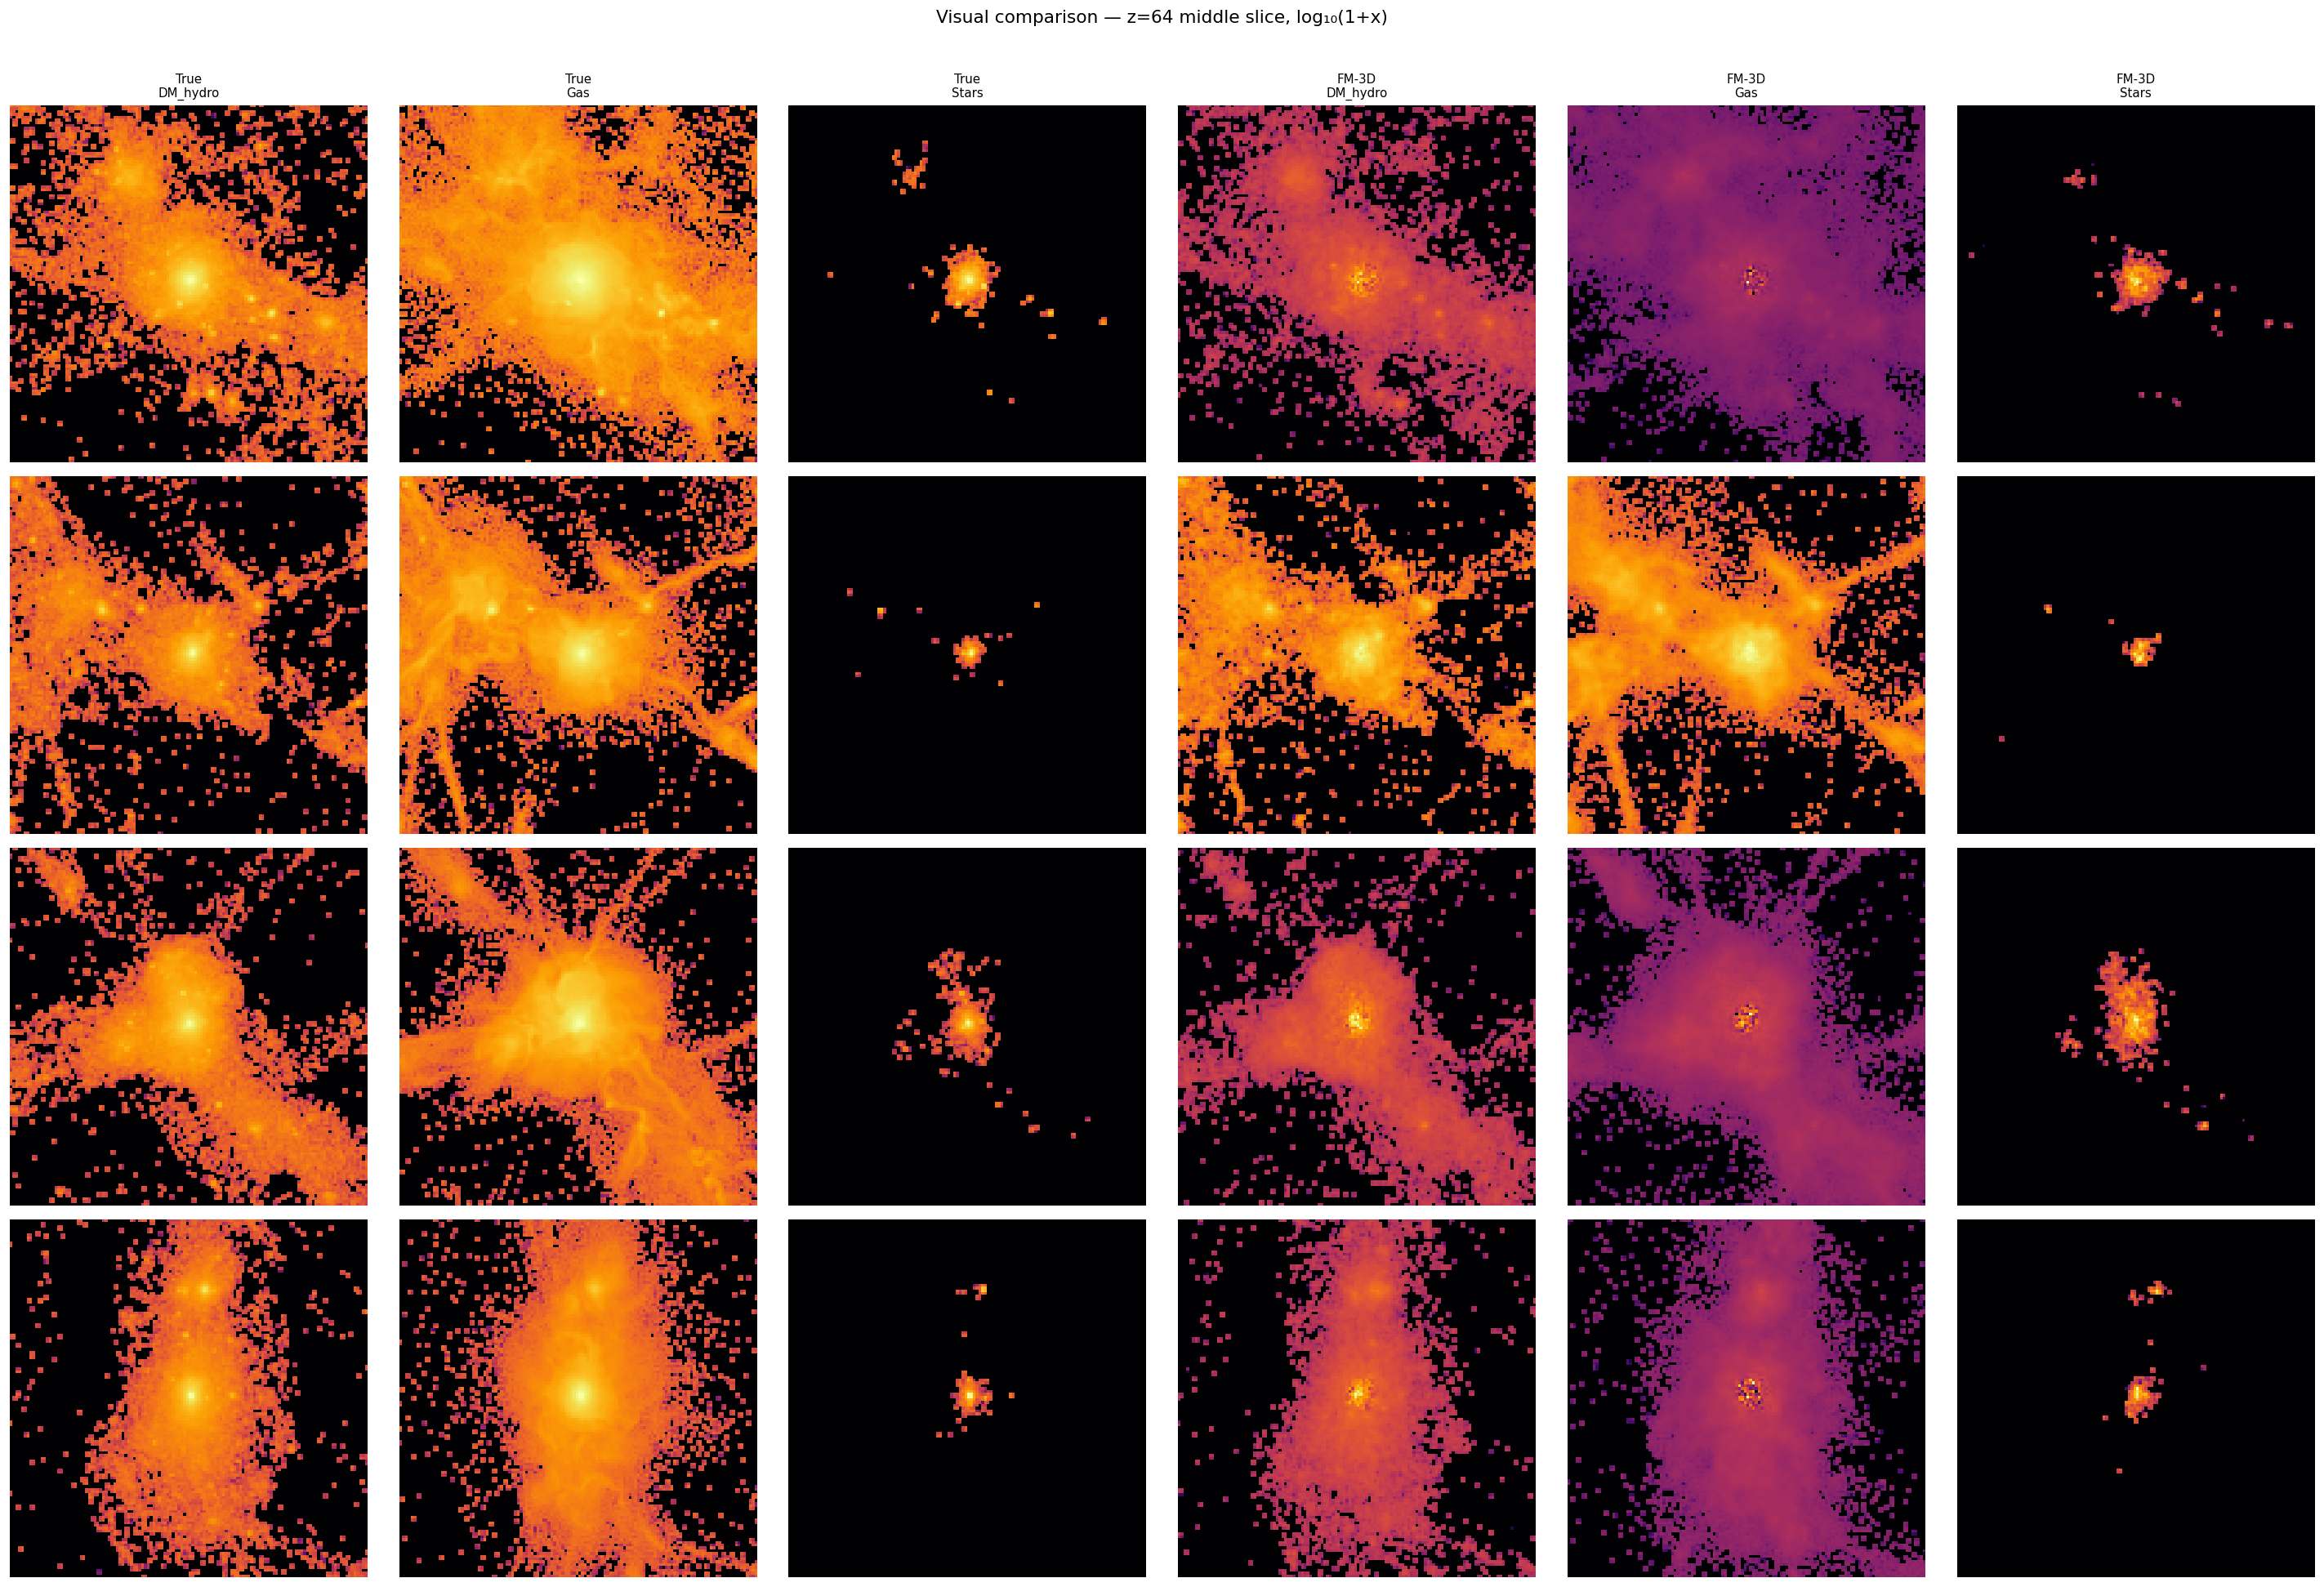

In [6]:
SLICE_Z    = CROP_SIZE // 2
N_SHOW     = 4
run_labels = list(results.keys())
n_cols     = 3 * (1 + len(run_labels))
show_idx   = np.linspace(0, len(real) - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(N_SHOW, n_cols, figsize=(4 * n_cols, 4 * N_SHOW))
for row, idx in enumerate(show_idx):
    for ch in range(3):
        ax = axes[row, ch]
        slc = real[idx, ch, SLICE_Z, :, :]
        ax.imshow(np.log10(slc + 1), cmap='inferno', origin='lower')
        if row == 0: ax.set_title(f'True\n{CHANNEL_NAMES[ch]}', fontsize=9)
        if ch == 0: ax.set_ylabel(f'vol {idx}', fontsize=8)
        ax.axis('off')
        for ri, lbl in enumerate(run_labels):
            col = 3 * (ri + 1) + ch
            ax2 = axes[row, col]
            slc_g = results[lbl]['gen'][idx, ch, SLICE_Z, :, :]
            ax2.imshow(np.log10(slc_g + 1), cmap='inferno', origin='lower')
            if row == 0: ax2.set_title(f'{lbl}\n{CHANNEL_NAMES[ch]}', fontsize=9)
            ax2.axis('off')

plt.suptitle(f'Visual comparison — z={SLICE_Z} middle slice, log₁₀(1+x)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

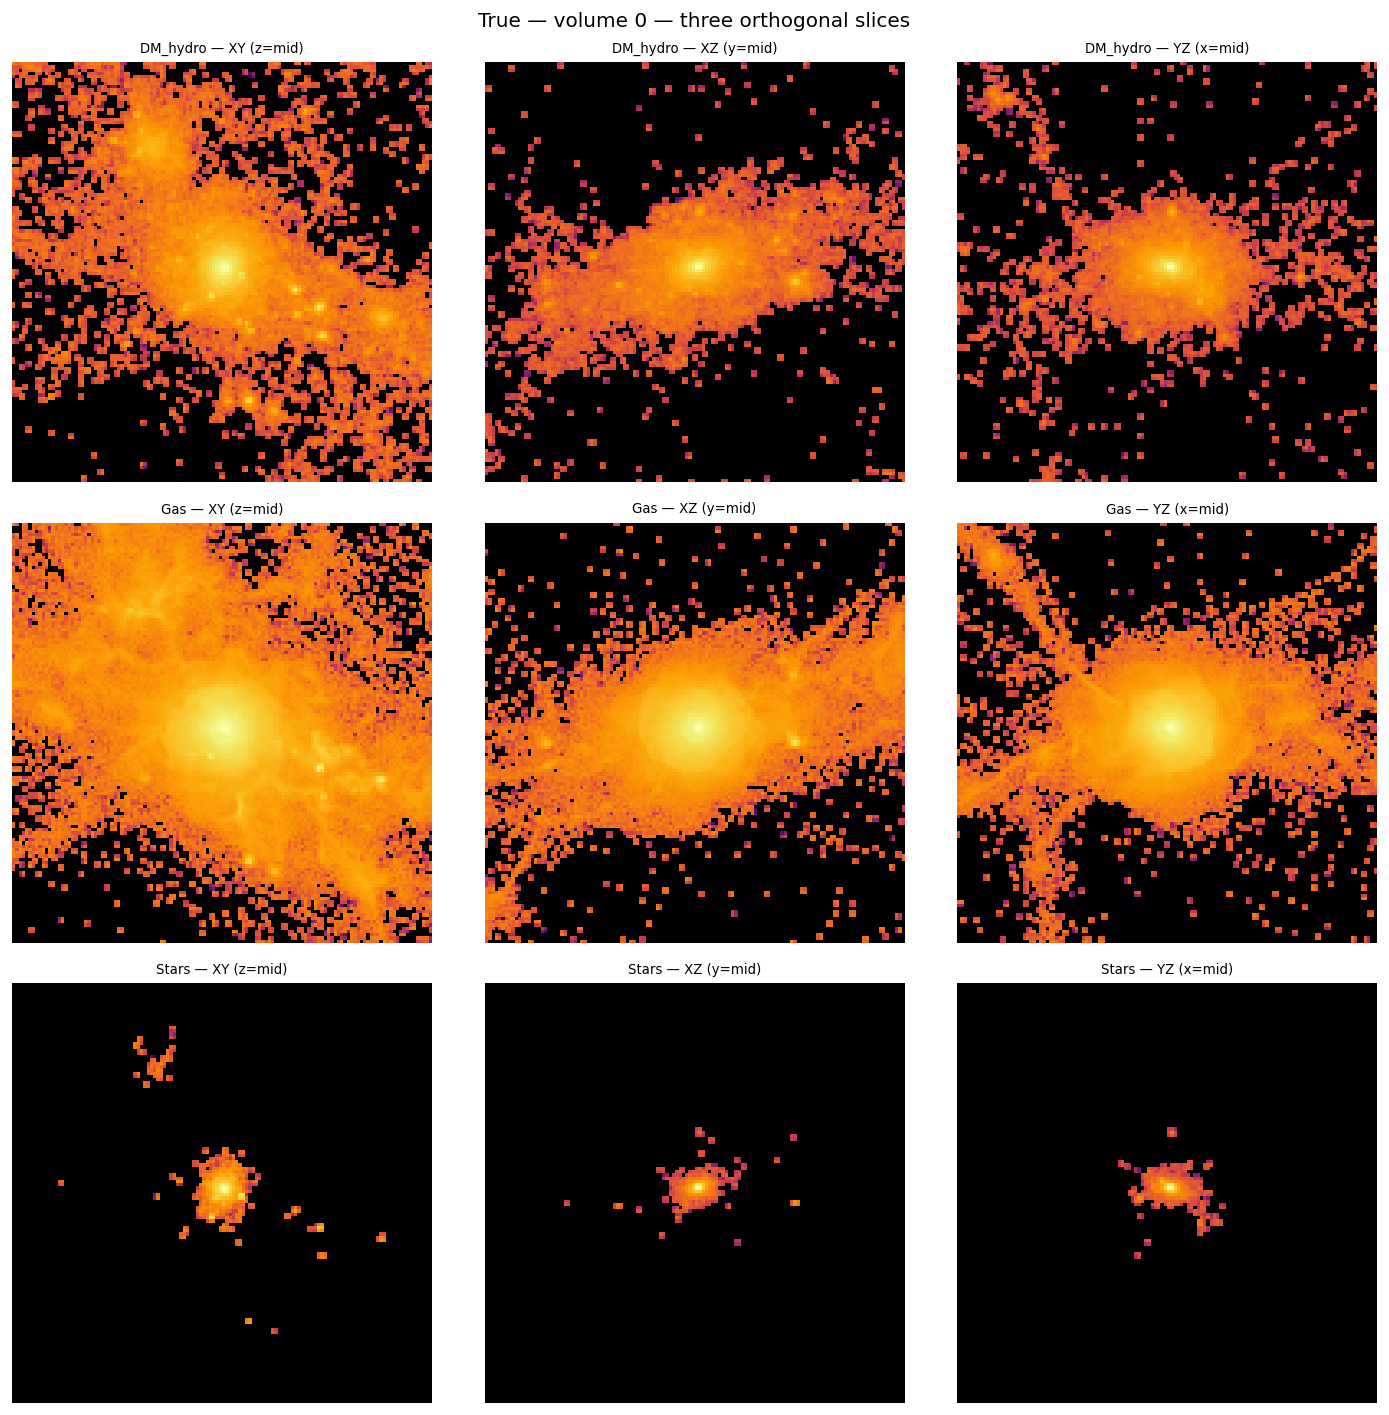

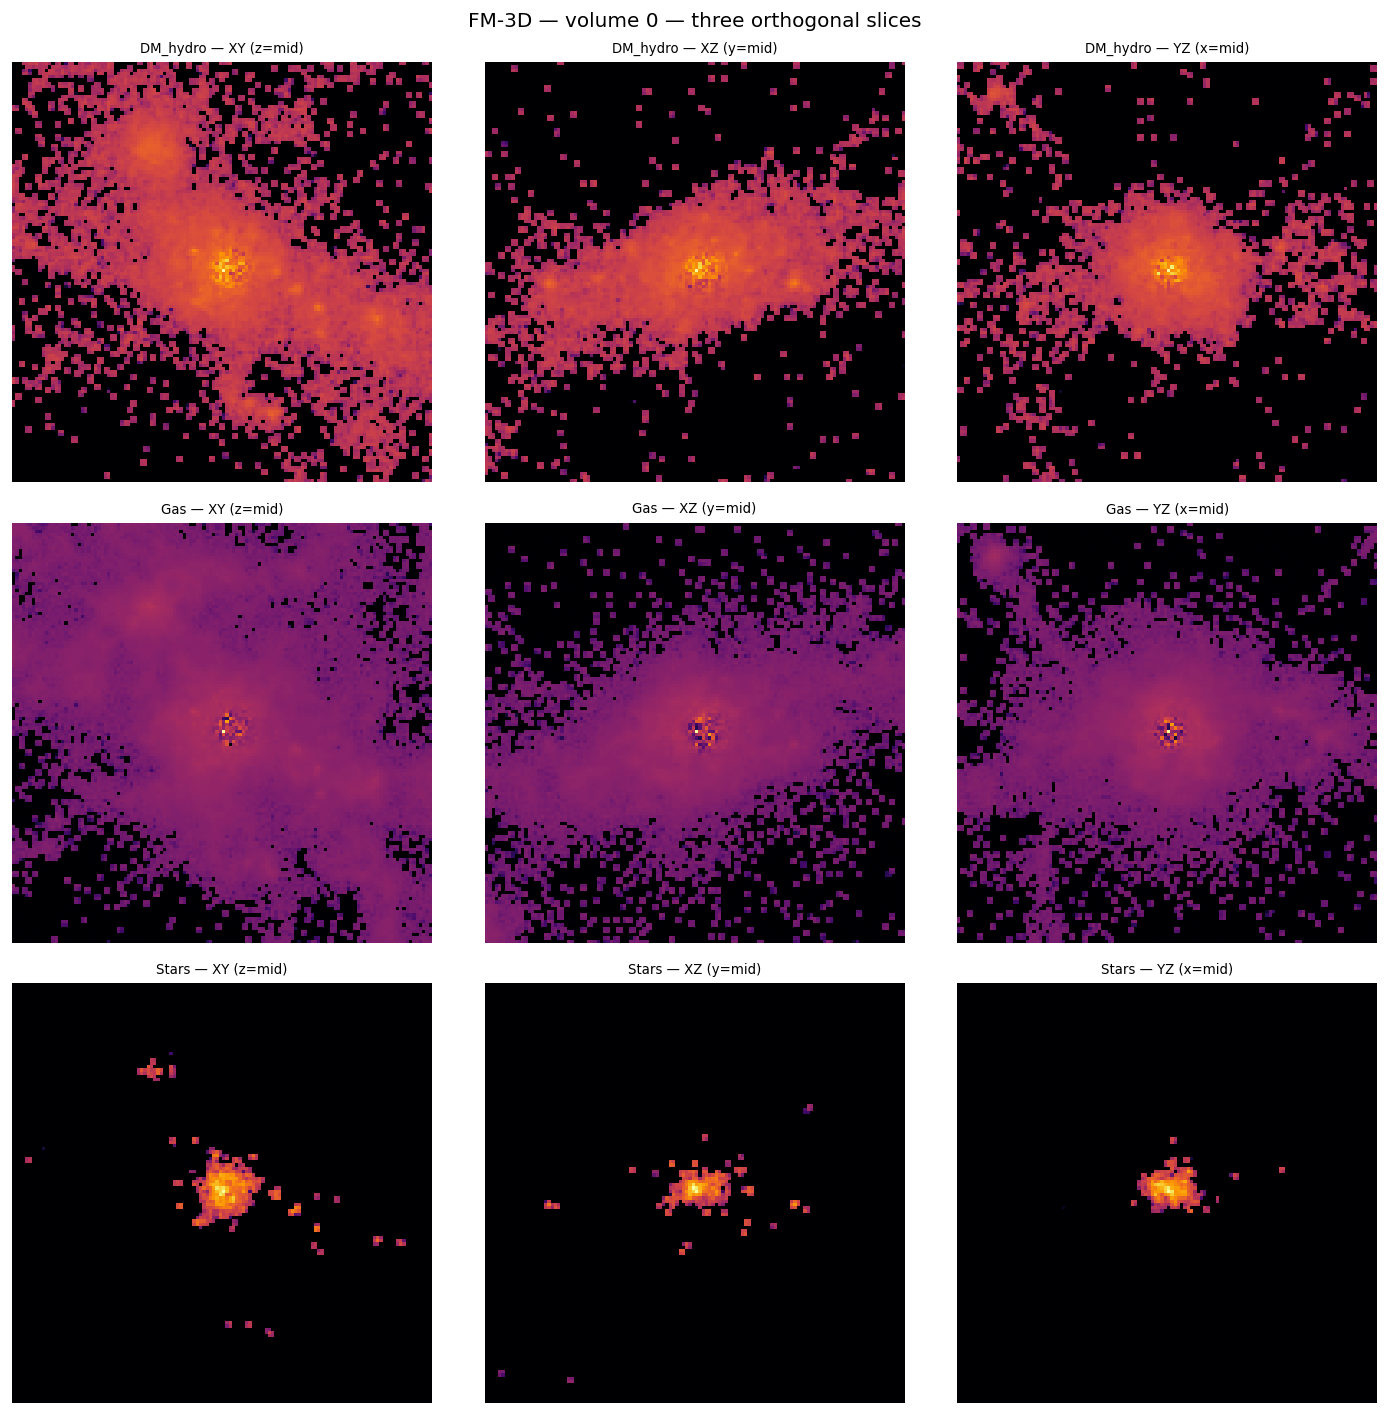

In [8]:
# Three orthogonal slices for one example volume
IDX = 0
for lbl in ['True'] + run_labels:
    vol = real[IDX] if lbl == 'True' else results[lbl]['gen'][IDX]
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for ch in range(3):
        mid = CROP_SIZE // 2
        for pi, (slc, plane) in enumerate([
            (vol[ch, mid, :, :], 'XY (z=mid)'),
            (vol[ch, :, mid, :], 'XZ (y=mid)'),
            (vol[ch, :, :, mid], 'YZ (x=mid)'),
        ]):
            ax = axes[ch, pi]
            ax.imshow(np.log10(slc + 1), cmap='inferno', origin='lower')
            ax.set_title(f'{CHANNEL_NAMES[ch]} — {plane}', fontsize=8)
            ax.axis('off')
    plt.suptitle(f'{lbl} — volume {IDX} — three orthogonal slices', fontsize=12)
    plt.tight_layout()
    plt.show()

## 2. Mass Matching
Total voxel sum per volume: emulated vs truth.

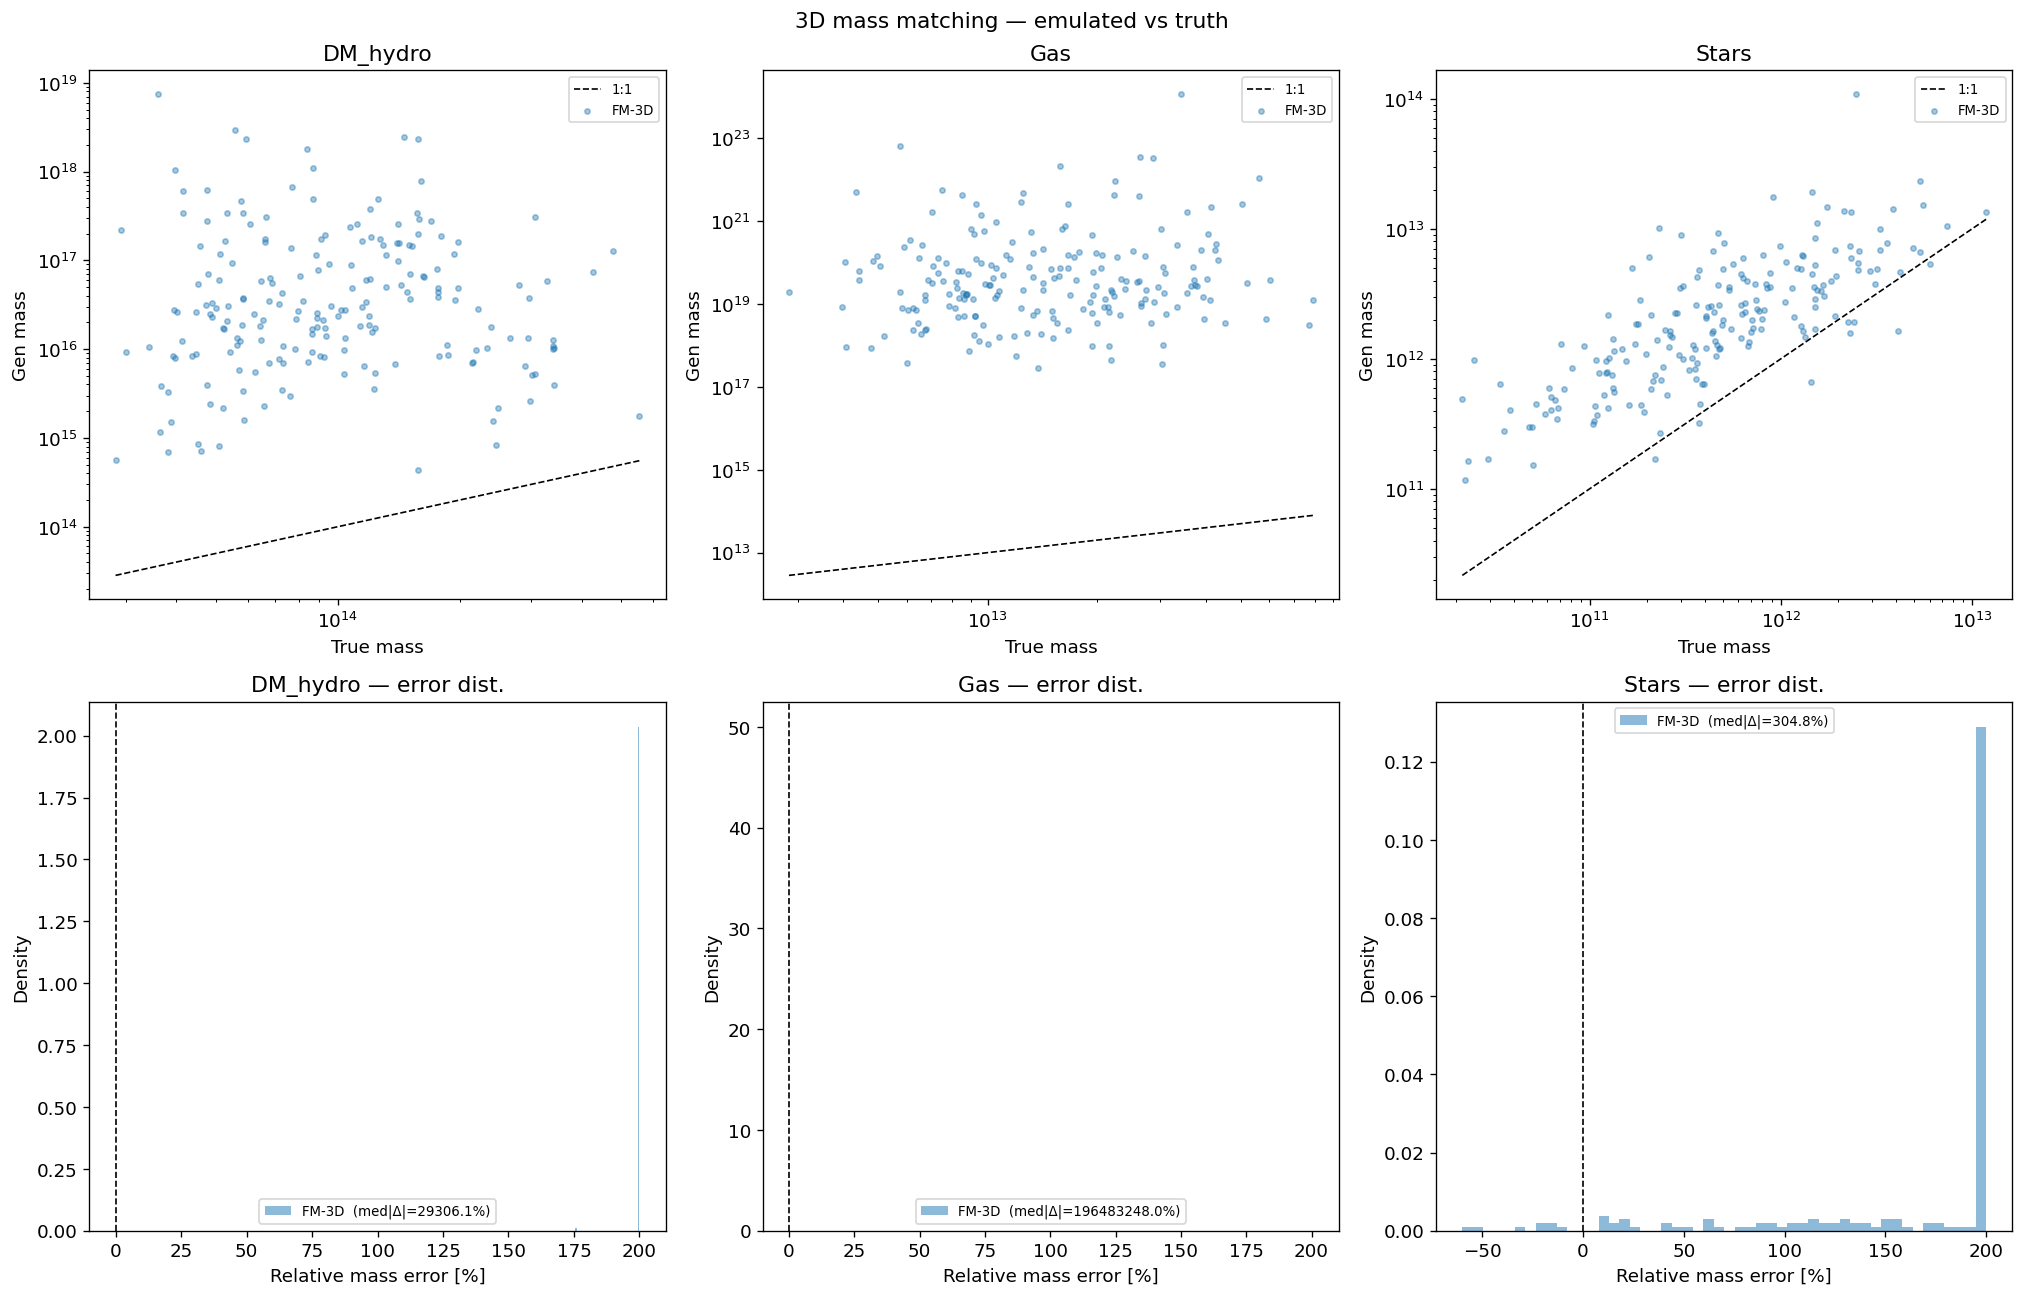


─── Median |relative mass error| per channel [%] ───
Channel            FM-3D
DM_hydro        29306.10
Gas         196483250.00
Stars             304.83


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))

for ch in range(3):
    m_true = real[:, ch].sum(axis=(-3, -2, -1))   # sum over D,H,W

    ax = axes[0, ch]
    ax.plot([m_true.min(), m_true.max()], [m_true.min(), m_true.max()],
            'k--', lw=1, label='1:1')
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        ax.scatter(m_true, m_gen, s=10, alpha=0.4, color=RUN_COLORS[lbl], label=lbl)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('True mass'); ax.set_ylabel('Gen mass')
    ax.set_title(CHANNEL_NAMES[ch]); ax.legend(fontsize=8)

    ax2 = axes[1, ch]
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        rel_err = (m_gen - m_true) / (m_true + 1e-30) * 100
        med = np.median(np.abs(rel_err))
        ax2.hist(np.clip(rel_err, -200, 200), bins=50, density=True,
                 alpha=0.5, color=RUN_COLORS[lbl],
                 label=f'{lbl}  (med|Δ|={med:.1f}%)')
    ax2.axvline(0, color='k', lw=1, ls='--')
    ax2.set_xlabel('Relative mass error [%]')
    ax2.set_ylabel('Density')
    ax2.set_title(f'{CHANNEL_NAMES[ch]} — error dist.')
    ax2.legend(fontsize=8)

plt.suptitle('3D mass matching — emulated vs truth', fontsize=13)
plt.tight_layout()
plt.show()

print('\n─── Median |relative mass error| per channel [%] ───')
hdr = f'{"Channel":<12}' + ''.join(f'{lbl:>12}' for lbl in results)
print(hdr)
for ch, name in enumerate(CHANNEL_NAMES):
    m_true = real[:, ch].sum(axis=(-3, -2, -1))
    row = f'{name:<12}'
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        err = np.median(np.abs((m_gen - m_true) / (m_true + 1e-30))) * 100
        row += f'{err:>12.2f}'
    print(row)

## 3. 3D Power Spectra
### 3a. Individual volume P(k) — batch mean ± std  
### 3b. Mean-field P(k) — catalog-level systematic check

Computing 3D power spectra (this takes a moment)...


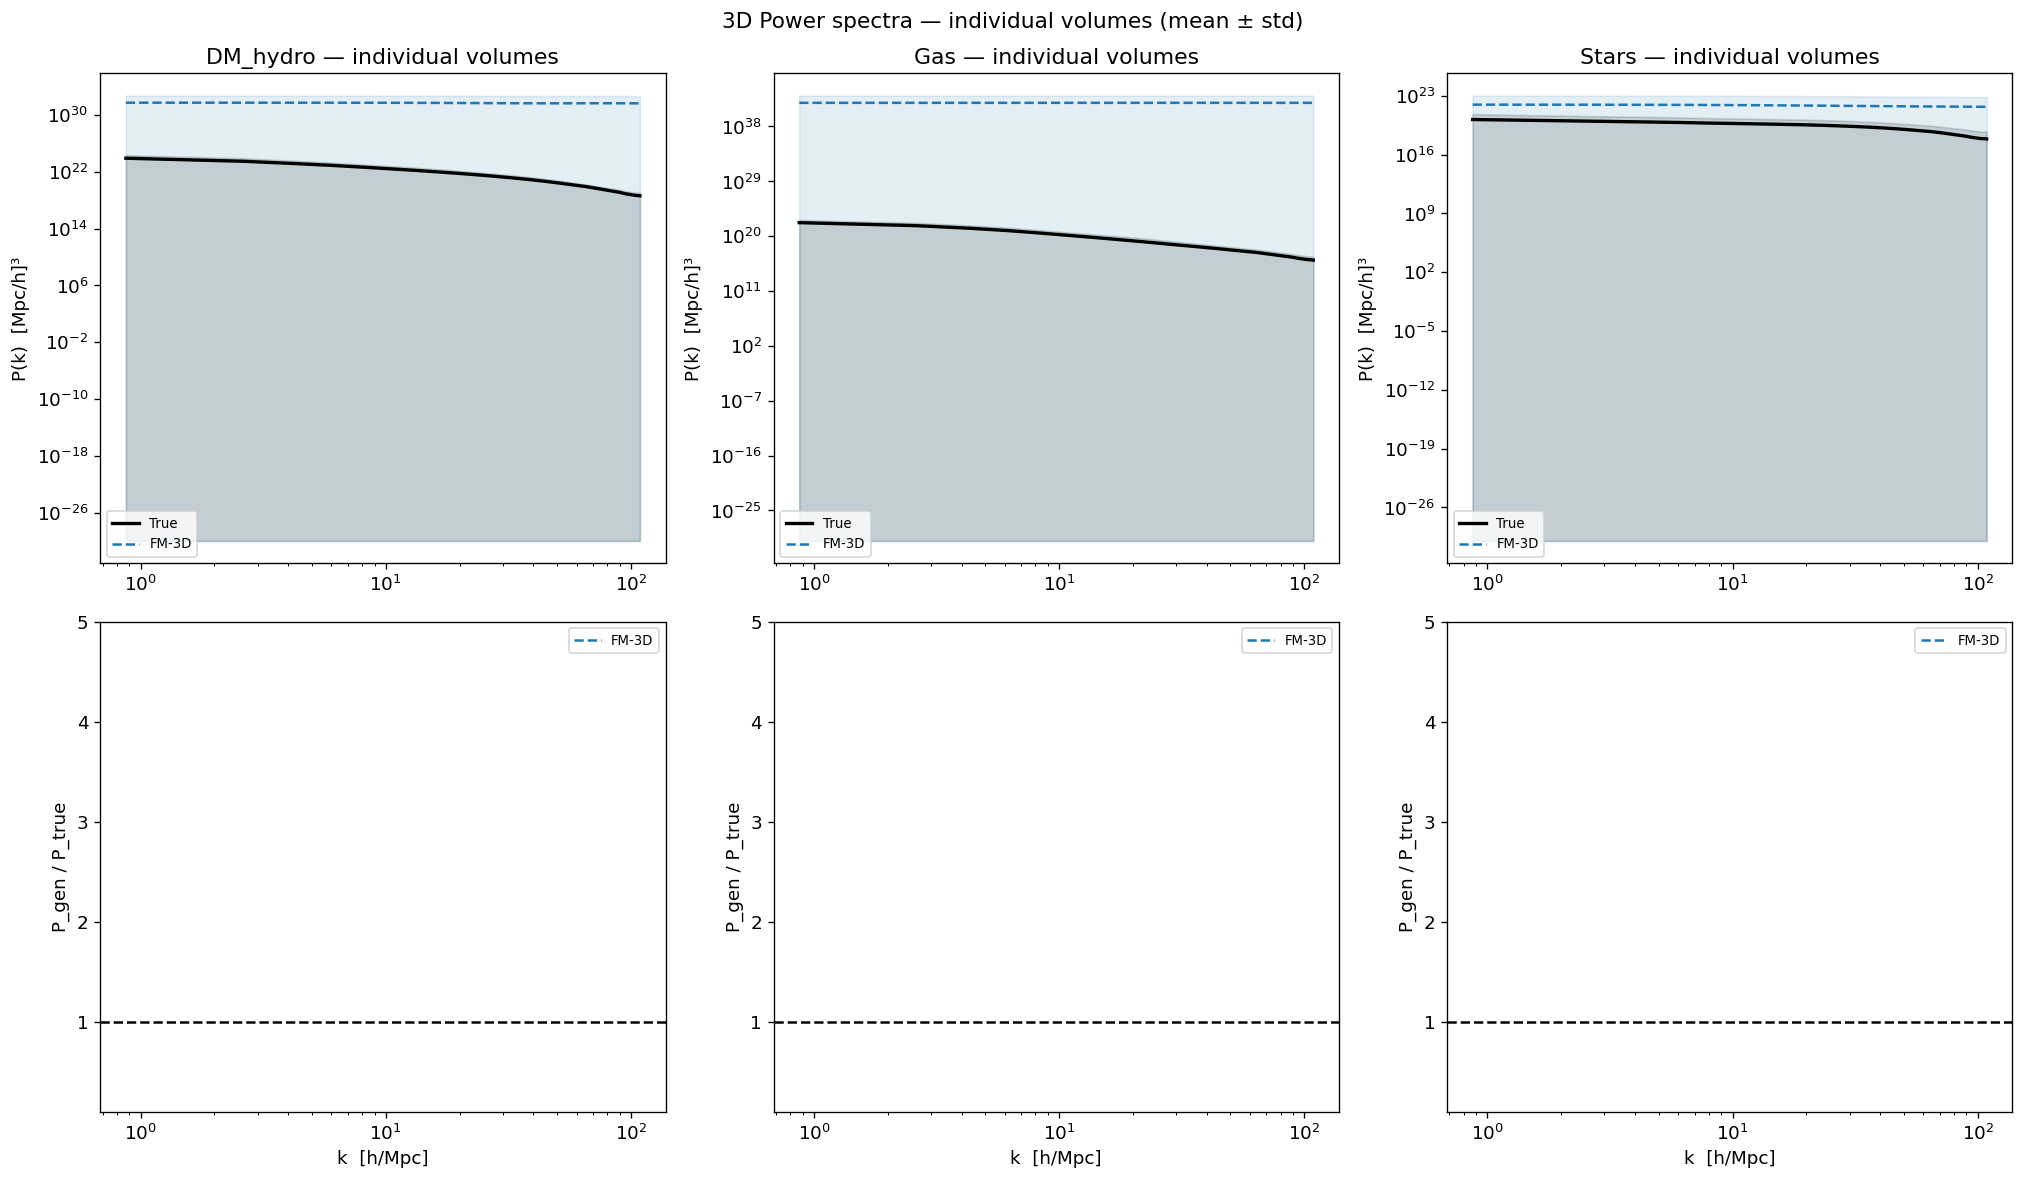

In [9]:
print('Computing 3D power spectra (this takes a moment)...')

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ch in range(3):
    k, pk_r, pk_r_std = batch_power_spectra_3d(real[:, ch], BOX_SIZE)
    ax_top = axes[0, ch]
    ax_bot = axes[1, ch]

    ax_top.loglog(k[k > 0], pk_r[k > 0], 'k-', lw=2, label='True')
    ax_top.fill_between(k[k > 0],
                        np.maximum(pk_r - pk_r_std, 1e-30)[k > 0],
                        (pk_r + pk_r_std)[k > 0],
                        alpha=0.15, color='k')
    ax_bot.axhline(1, color='k', lw=1.5, ls='--')

    for lbl, res in results.items():
        c = RUN_COLORS[lbl]
        _, pk_g, pk_g_std = batch_power_spectra_3d(res['gen'][:, ch], BOX_SIZE)
        ax_top.loglog(k[k > 0], pk_g[k > 0], '--', color=c, lw=1.5, label=lbl)
        ax_top.fill_between(k[k > 0],
                            np.maximum(pk_g - pk_g_std, 1e-30)[k > 0],
                            (pk_g + pk_g_std)[k > 0],
                            alpha=0.12, color=c)
        ratio = pk_g / (pk_r + 1e-30)
        ax_bot.semilogx(k[k > 0], ratio[k > 0], '--', color=c, lw=1.5, label=lbl)

    ax_top.set_ylabel('P(k)  [Mpc/h]³')
    ax_top.set_title(f'{CHANNEL_NAMES[ch]} — individual volumes')
    ax_top.legend(fontsize=8)
    ax_bot.set_xlabel('k  [h/Mpc]')
    ax_bot.set_ylabel('P_gen / P_true')
    ax_bot.set_ylim(0.1, 5.0)
    ax_bot.legend(fontsize=8)

plt.suptitle('3D Power spectra — individual volumes (mean ± std)', fontsize=13)
plt.tight_layout()
plt.show()

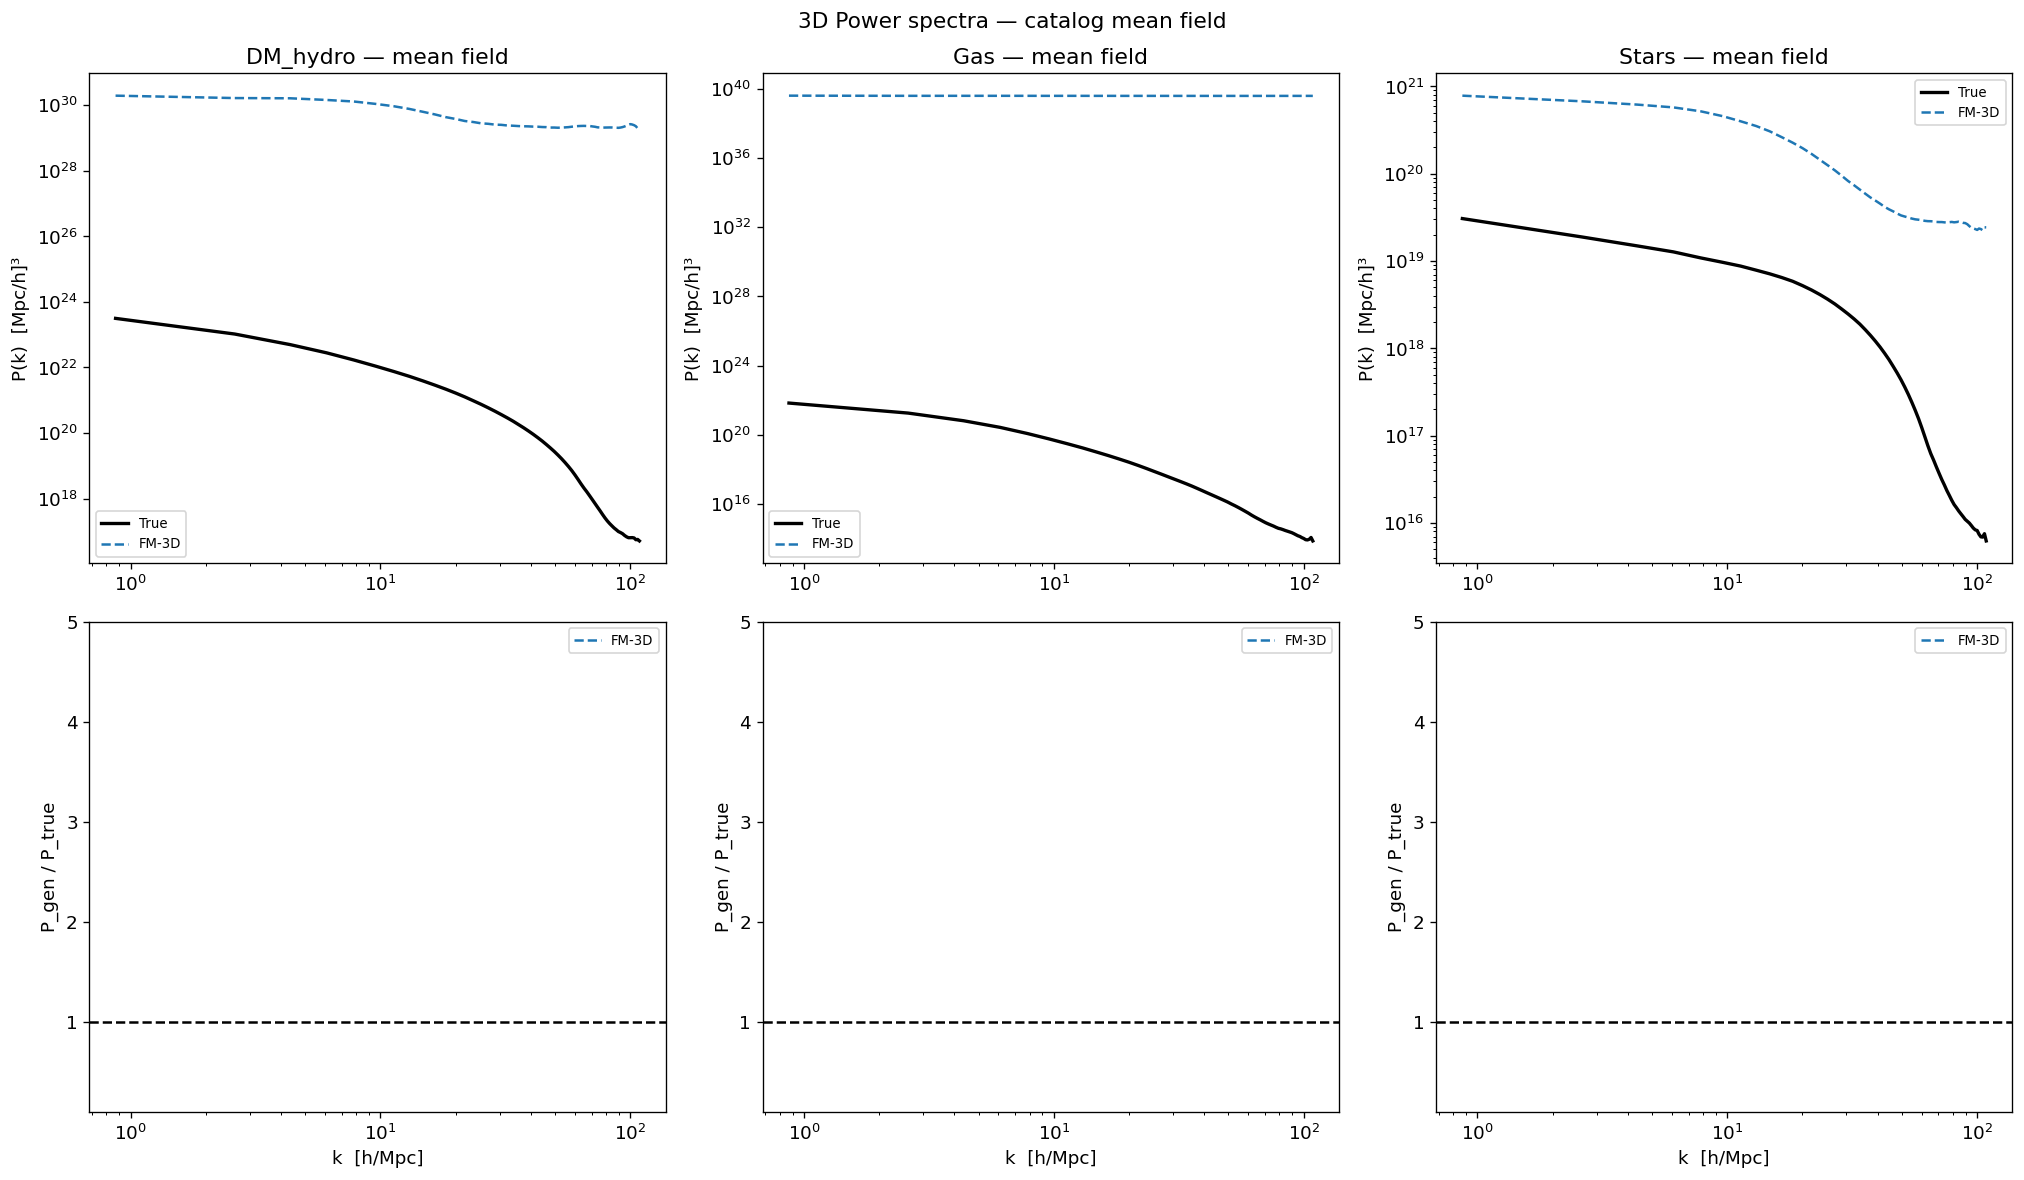


─── Mean-field P(k): median |log10(gen/true)| ───
Channel            FM-3D
DM_hydro         10.2192
Gas              23.7691
Stars             2.1045


In [10]:
# Catalog-level: P(k) of mean field over test set
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ch in range(3):
    mean_true = real[:, ch].mean(axis=0)  # (64, 64, 64)
    k, pk_r = power_spectrum_3d(mean_true, BOX_SIZE)

    ax_top = axes[0, ch]
    ax_bot = axes[1, ch]
    mask = k > 0

    ax_top.loglog(k[mask], pk_r[mask], 'k-', lw=2, label='True')
    ax_bot.axhline(1, color='k', lw=1.5, ls='--')

    for lbl, res in results.items():
        c = RUN_COLORS[lbl]
        mean_gen = res['gen'][:, ch].mean(axis=0)
        _, pk_g = power_spectrum_3d(mean_gen, BOX_SIZE)
        ax_top.loglog(k[mask], pk_g[mask], '--', color=c, lw=1.5, label=lbl)
        ratio = pk_g / (pk_r + 1e-30)
        ax_bot.semilogx(k[mask], ratio[mask], '--', color=c, lw=1.5, label=lbl)

    ax_top.set_ylabel('P(k)  [Mpc/h]³')
    ax_top.set_title(f'{CHANNEL_NAMES[ch]} — mean field')
    ax_top.legend(fontsize=8)
    ax_bot.set_xlabel('k  [h/Mpc]')
    ax_bot.set_ylabel('P_gen / P_true')
    ax_bot.set_ylim(0.1, 5.0)
    ax_bot.legend(fontsize=8)

plt.suptitle('3D Power spectra — catalog mean field', fontsize=13)
plt.tight_layout()
plt.show()

print('\n─── Mean-field P(k): median |log10(gen/true)| ───')
hdr = f'{"Channel":<12}' + ''.join(f'{lbl:>12}' for lbl in results)
print(hdr)
for ch, name in enumerate(CHANNEL_NAMES):
    mean_true = real[:, ch].mean(axis=0)
    k, pk_r = power_spectrum_3d(mean_true, BOX_SIZE)
    mask = (k > 0) & (pk_r > 0)
    row = f'{name:<12}'
    for lbl, res in results.items():
        mean_gen = res['gen'][:, ch].mean(axis=0)
        _, pk_g = power_spectrum_3d(mean_gen, BOX_SIZE)
        err = np.median(np.abs(np.log10(pk_g[mask] / pk_r[mask] + 1e-10)))
        row += f'{err:>12.4f}'
    print(row)

## 4. 3D Radial Profiles
Mean voxel value as a function of 3D distance from the volume centre.  
r_max = 32 voxels = 3.125 Mpc/h (to box edge).

Computing 3D radial profiles...


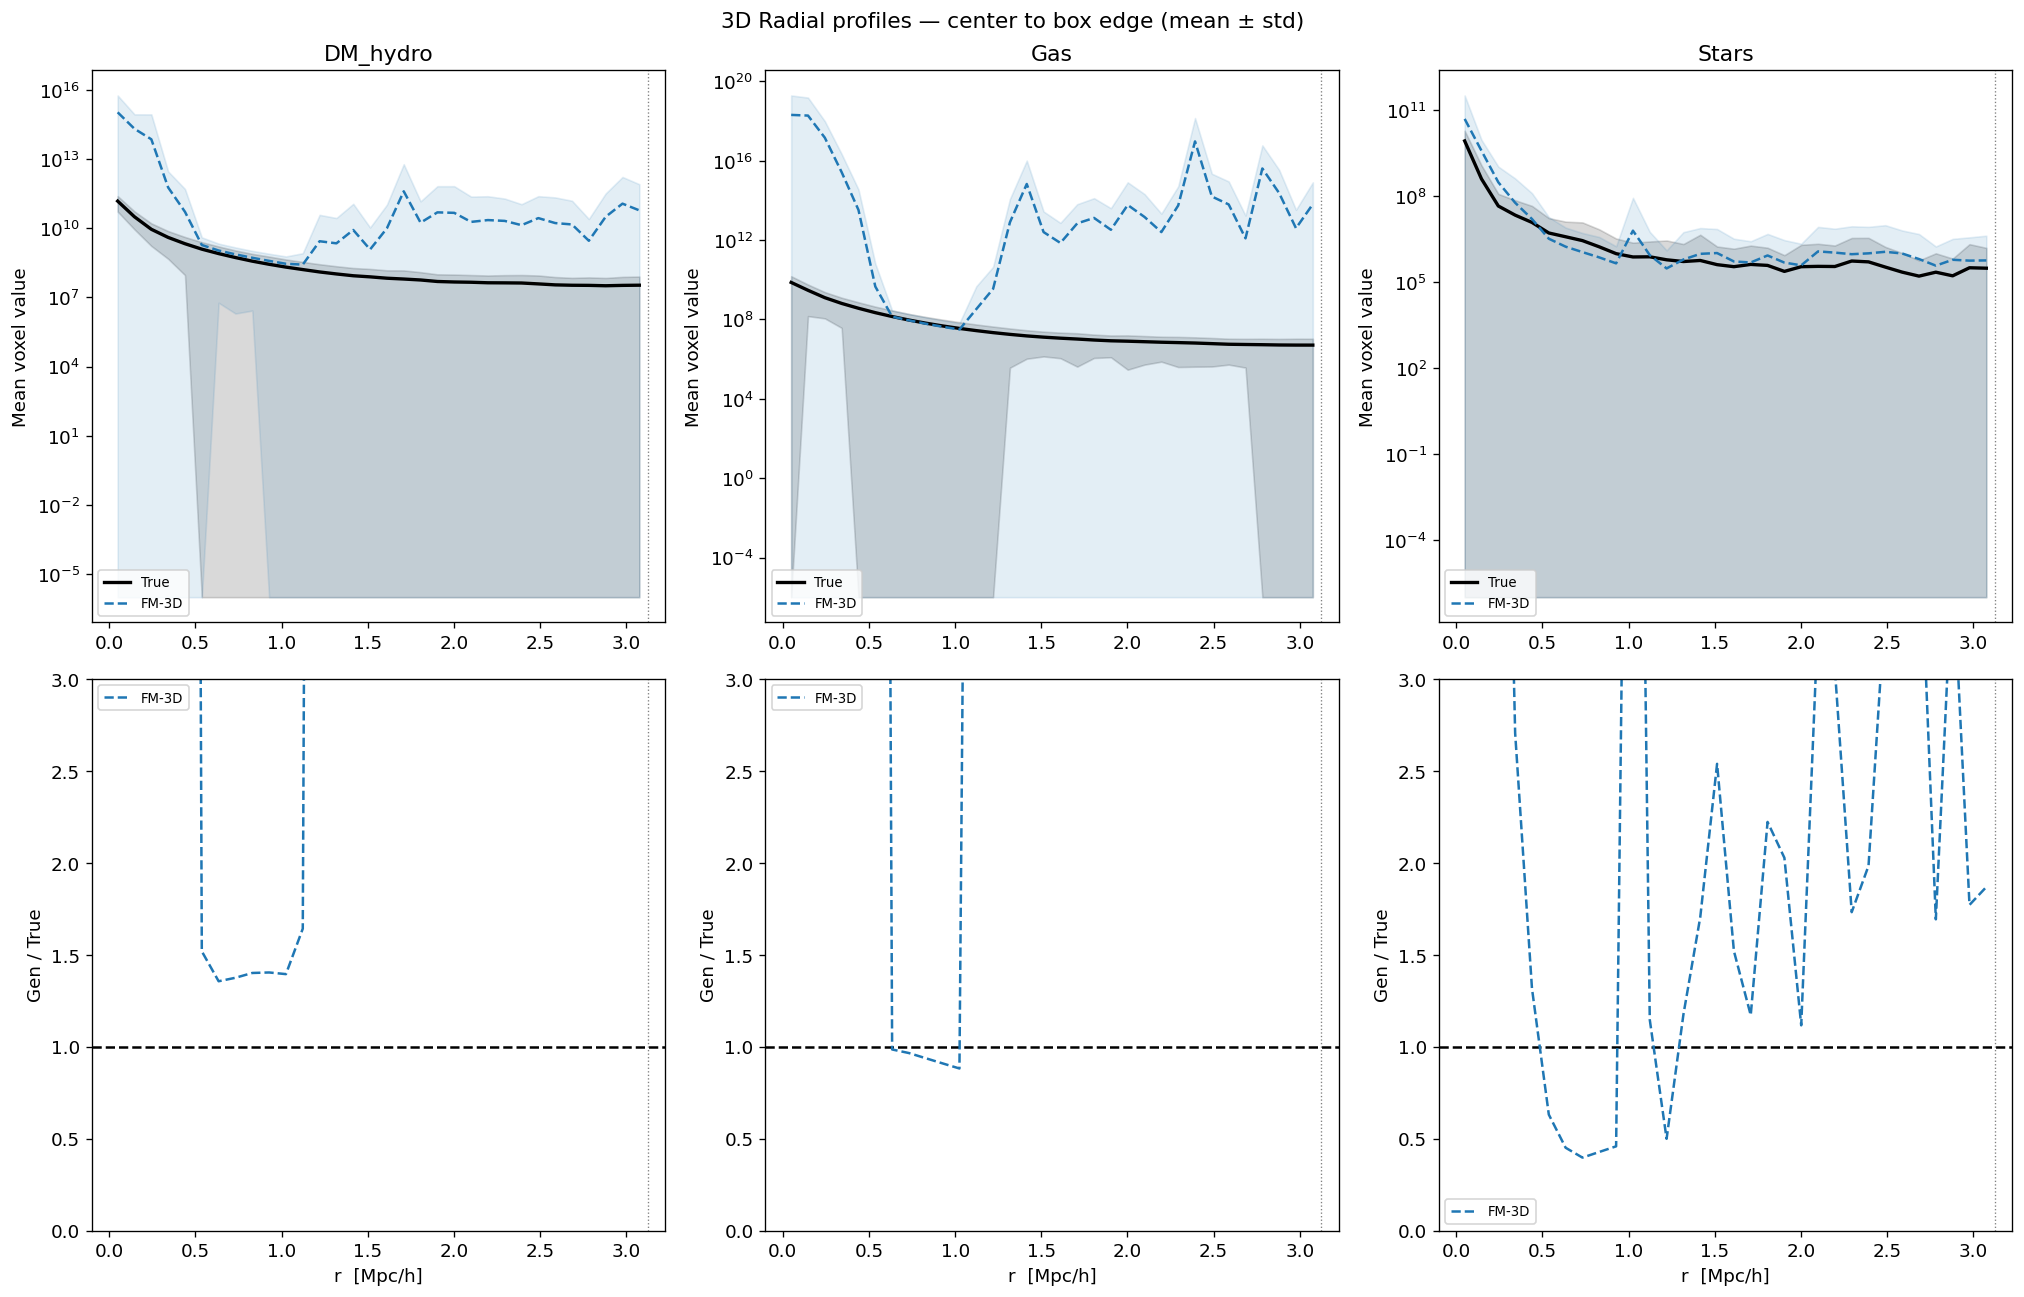

In [11]:
N_BINS = 32
print('Computing 3D radial profiles...')

fig, axes = plt.subplots(2, 3, figsize=(17, 11))

for ch in range(3):
    r_pix, pr_mean, pr_std = batch_profiles_3d(real[:, ch], n_bins=N_BINS)
    r_mpc = r_pix * PIX_SIZE

    ax_top = axes[0, ch]
    ax_bot = axes[1, ch]

    ax_top.semilogy(r_mpc, pr_mean + 1e-6, 'k-', lw=2, label='True')
    ax_top.fill_between(r_mpc,
                        np.maximum(pr_mean - pr_std, 1e-6),
                        pr_mean + pr_std + 1e-6,
                        alpha=0.15, color='k')
    ax_bot.axhline(1, color='k', lw=1.5, ls='--')

    for lbl, res in results.items():
        c = RUN_COLORS[lbl]
        _, pg_mean, pg_std = batch_profiles_3d(res['gen'][:, ch], n_bins=N_BINS)
        ax_top.semilogy(r_mpc, pg_mean + 1e-6, '--', color=c, lw=1.5, label=lbl)
        ax_top.fill_between(r_mpc,
                            np.maximum(pg_mean - pg_std, 1e-6),
                            pg_mean + pg_std + 1e-6,
                            alpha=0.12, color=c)
        ratio = (pg_mean + 1e-8) / (pr_mean + 1e-8)
        ax_bot.plot(r_mpc, ratio, '--', color=c, lw=1.5, label=lbl)

    ax_top.set_ylabel('Mean voxel value')
    ax_top.set_title(CHANNEL_NAMES[ch])
    ax_top.legend(fontsize=8)
    ax_bot.set_xlabel('r  [Mpc/h]')
    ax_bot.set_ylabel('Gen / True')
    ax_bot.set_ylim(0.0, 3.0)
    ax_bot.legend(fontsize=8)
    for ax in (ax_top, ax_bot):
        ax.axvline(BOX_SIZE / 2, color='gray', lw=0.8, ls=':', label='box edge')

plt.suptitle('3D Radial profiles — center to box edge (mean ± std)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. In-Distribution Check
### 5a. Voxel value distributions + KS test
### 5b. 2D joint distributions (scaling relations)
### 5c. Volume total mass function
### 5d. Stellar occupancy

─── Two-sample KS test: generated vs truth ───
  DM_hydro     FM-3D: KS=0.0208, p=0.000e+00
  Gas          FM-3D: KS=0.4619, p=0.000e+00
  Stars        FM-3D: KS=0.5276, p=0.000e+00


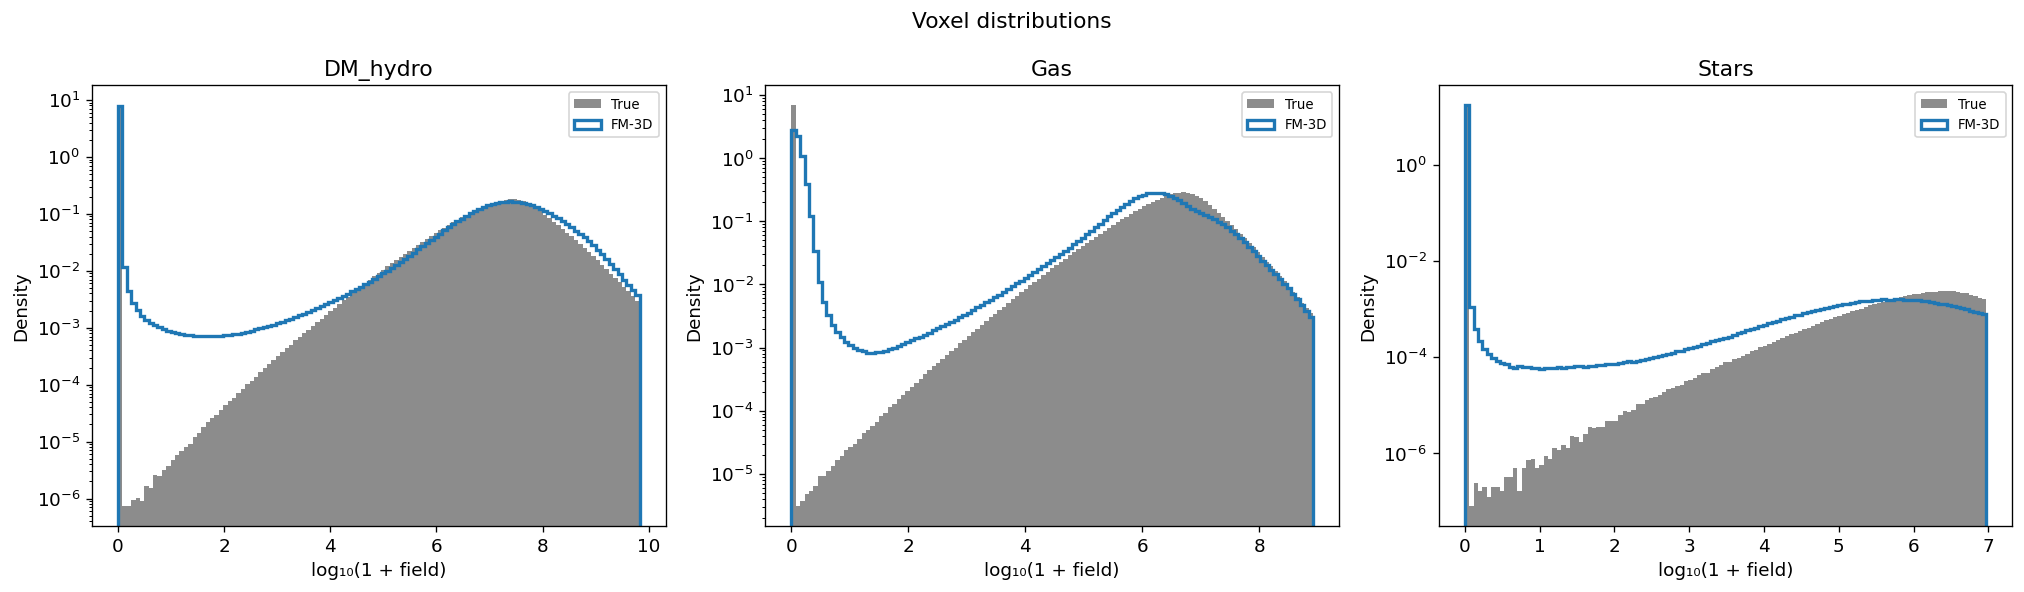

In [12]:
# 5a. Voxel distributions
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
print('─── Two-sample KS test: generated vs truth ───')

for ch in range(3):
    r_flat = np.log10(real[:, ch].flatten() + 1)
    p99 = np.percentile(r_flat, 99.9)
    bins = np.linspace(0, p99, 120)
    ax = axes[ch]
    ax.hist(r_flat, bins=bins, density=True, alpha=0.45, color='k', label='True')
    for lbl, res in results.items():
        g_flat = np.log10(res['gen'][:, ch].flatten() + 1)
        ax.hist(g_flat, bins=bins, density=True, histtype='step',
                lw=2, color=RUN_COLORS[lbl], label=lbl)
        ks_stat, ks_p = stats.ks_2samp(r_flat[::50], g_flat[::50])
        print(f'  {CHANNEL_NAMES[ch]:12s} {lbl}: KS={ks_stat:.4f}, p={ks_p:.3e}')
    ax.set_xlabel('log₁₀(1 + field)')
    ax.set_ylabel('Density')
    ax.set_yscale('log')
    ax.set_title(CHANNEL_NAMES[ch])
    ax.legend(fontsize=8)

plt.suptitle('Voxel distributions', fontsize=13)
plt.tight_layout()
plt.show()

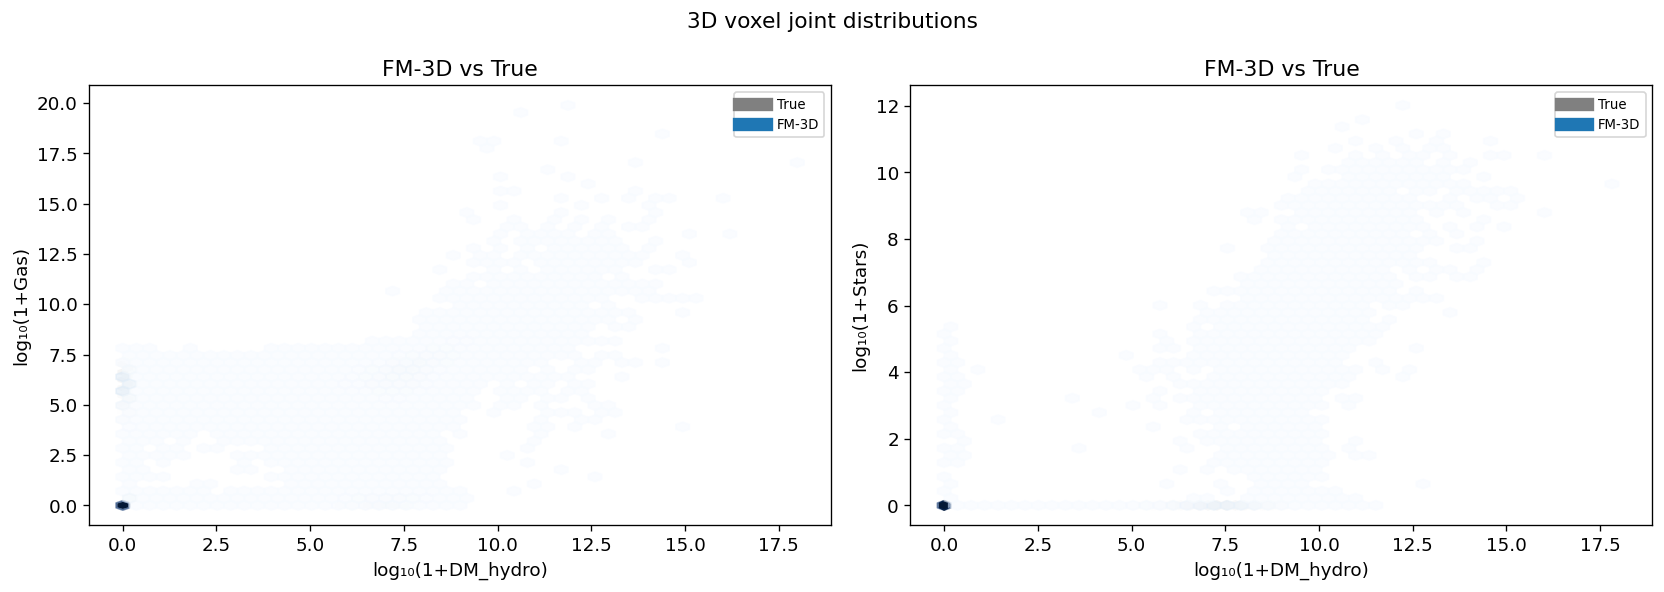

In [13]:
# 5b. 2D joint distributions: Gas vs DM, Stars vs DM
subsample = 200  # every N-th voxel — 3D arrays are large

fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

log_dm_true   = np.log10(real[:, 0].flatten()[::subsample] + 1)
log_gas_true  = np.log10(real[:, 1].flatten()[::subsample] + 1)
log_star_true = np.log10(real[:, 2].flatten()[::subsample] + 1)

for ri, (lbl, res) in enumerate(results.items()):
    log_dm_g   = np.log10(res['gen'][:, 0].flatten()[::subsample] + 1)
    log_gas_g  = np.log10(res['gen'][:, 1].flatten()[::subsample] + 1)
    log_star_g = np.log10(res['gen'][:, 2].flatten()[::subsample] + 1)

    for col, (x_t, y_t, x_g, y_g, ylabel) in enumerate([
        (log_dm_true, log_gas_true,  log_dm_g, log_gas_g,  'log₁₀(1+Gas)'),
        (log_dm_true, log_star_true, log_dm_g, log_star_g, 'log₁₀(1+Stars)'),
    ]):
        ax = axes[ri, col]
        ax.hexbin(x_t, y_t, gridsize=50, cmap='Greys', mincnt=1)
        ax.hexbin(x_g, y_g, gridsize=50,
                  cmap=plt.cm.Blues if 'FM' in lbl else plt.cm.Oranges,
                  mincnt=1, alpha=0.5)
        ax.set_xlabel('log₁₀(1+DM_hydro)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{lbl} vs True')
        ax.legend(handles=[
            plt.Line2D([0],[0], color='gray', lw=8, label='True'),
            plt.Line2D([0],[0], color=RUN_COLORS[lbl], lw=8, label=lbl),
        ], fontsize=8)

plt.suptitle('3D voxel joint distributions', fontsize=13)
plt.tight_layout()
plt.show()

/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


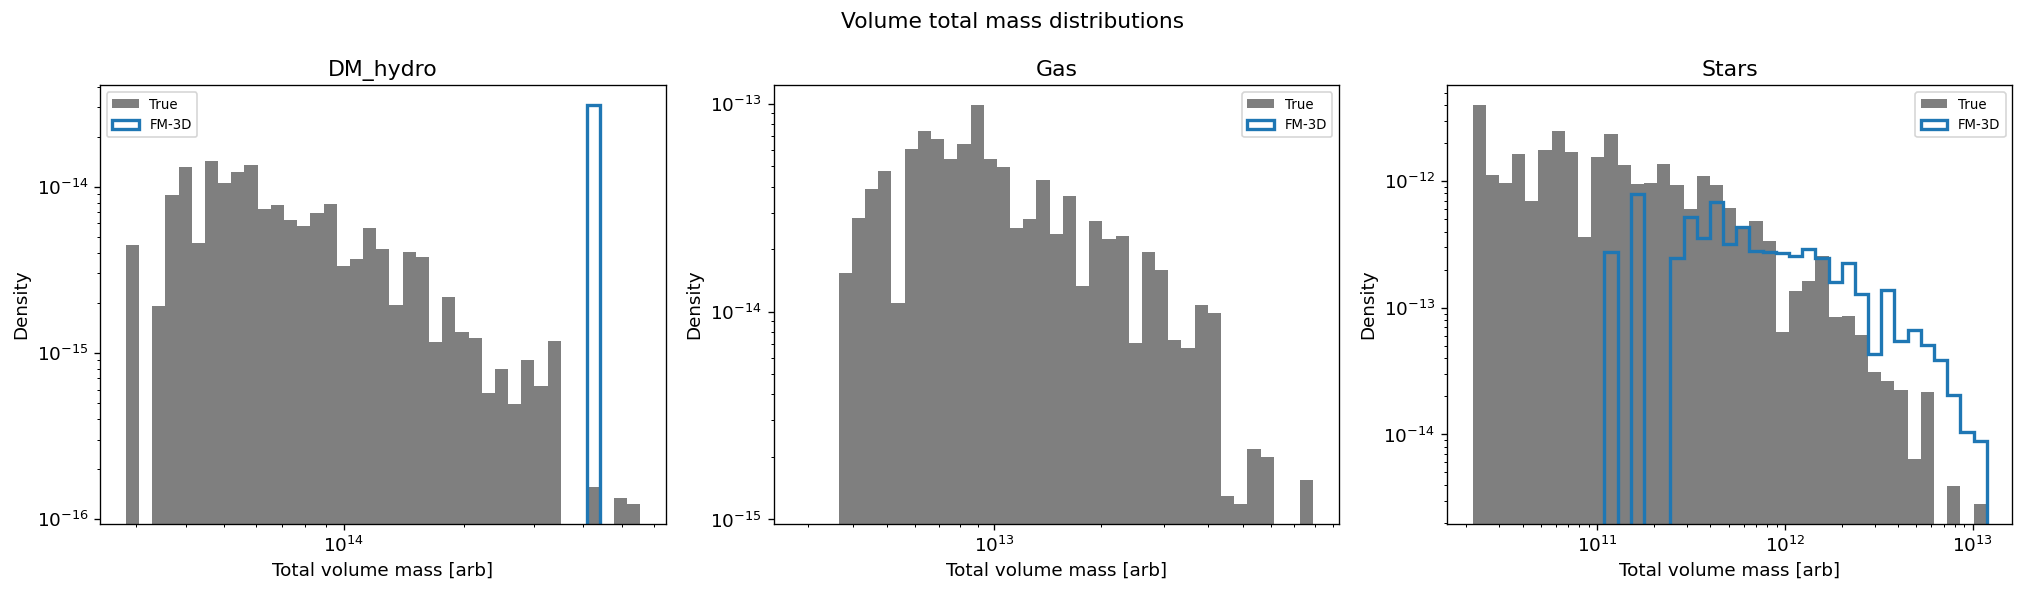


─── Stellar occupancy (fraction of voxels with M* > threshold) ───
  True: 0.48%
  FM-3D: 45.24%  (Δ = +44.76 pp)


In [14]:
# 5c. Volume total mass + 5d. Stellar occupancy
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ch in range(3):
    ax = axes[ch]
    m_true = real[:, ch].sum(axis=(-3, -2, -1))
    pos_mask = m_true > 0
    if pos_mask.any():
        bins = np.logspace(np.log10(m_true[pos_mask].min() + 1),
                           np.log10(m_true.max() + 1), 40)
    else:
        bins = 40
    ax.hist(m_true + 1, bins=bins, density=True, alpha=0.5, color='k', label='True')
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        ax.hist(m_gen + 1, bins=bins, density=True, histtype='step',
                lw=2, color=RUN_COLORS[lbl], label=lbl)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Total volume mass [arb]')
    ax.set_ylabel('Density')
    ax.set_title(CHANNEL_NAMES[ch])
    ax.legend(fontsize=8)

plt.suptitle('Volume total mass distributions', fontsize=13)
plt.tight_layout()
plt.show()

print('\n─── Stellar occupancy (fraction of voxels with M* > threshold) ───')
true_occ = (real[:, 2] > STAR_THRESH).mean() * 100
print(f'  True: {true_occ:.2f}%')
for lbl, res in results.items():
    gen_occ = (res['gen'][:, 2] > STAR_THRESH).mean() * 100
    print(f'  {lbl}: {gen_occ:.2f}%  (Δ = {gen_occ - true_occ:+.2f} pp)')

## 6. Parameter Sensitivity — Field-Level Differences
Split test volumes into high/low groups along two cosmological parameters.
Good emulators should produce correlated Δ maps with the truth.


Param [0]  lo: 0.402  hi: 0.919  (50 volumes each)


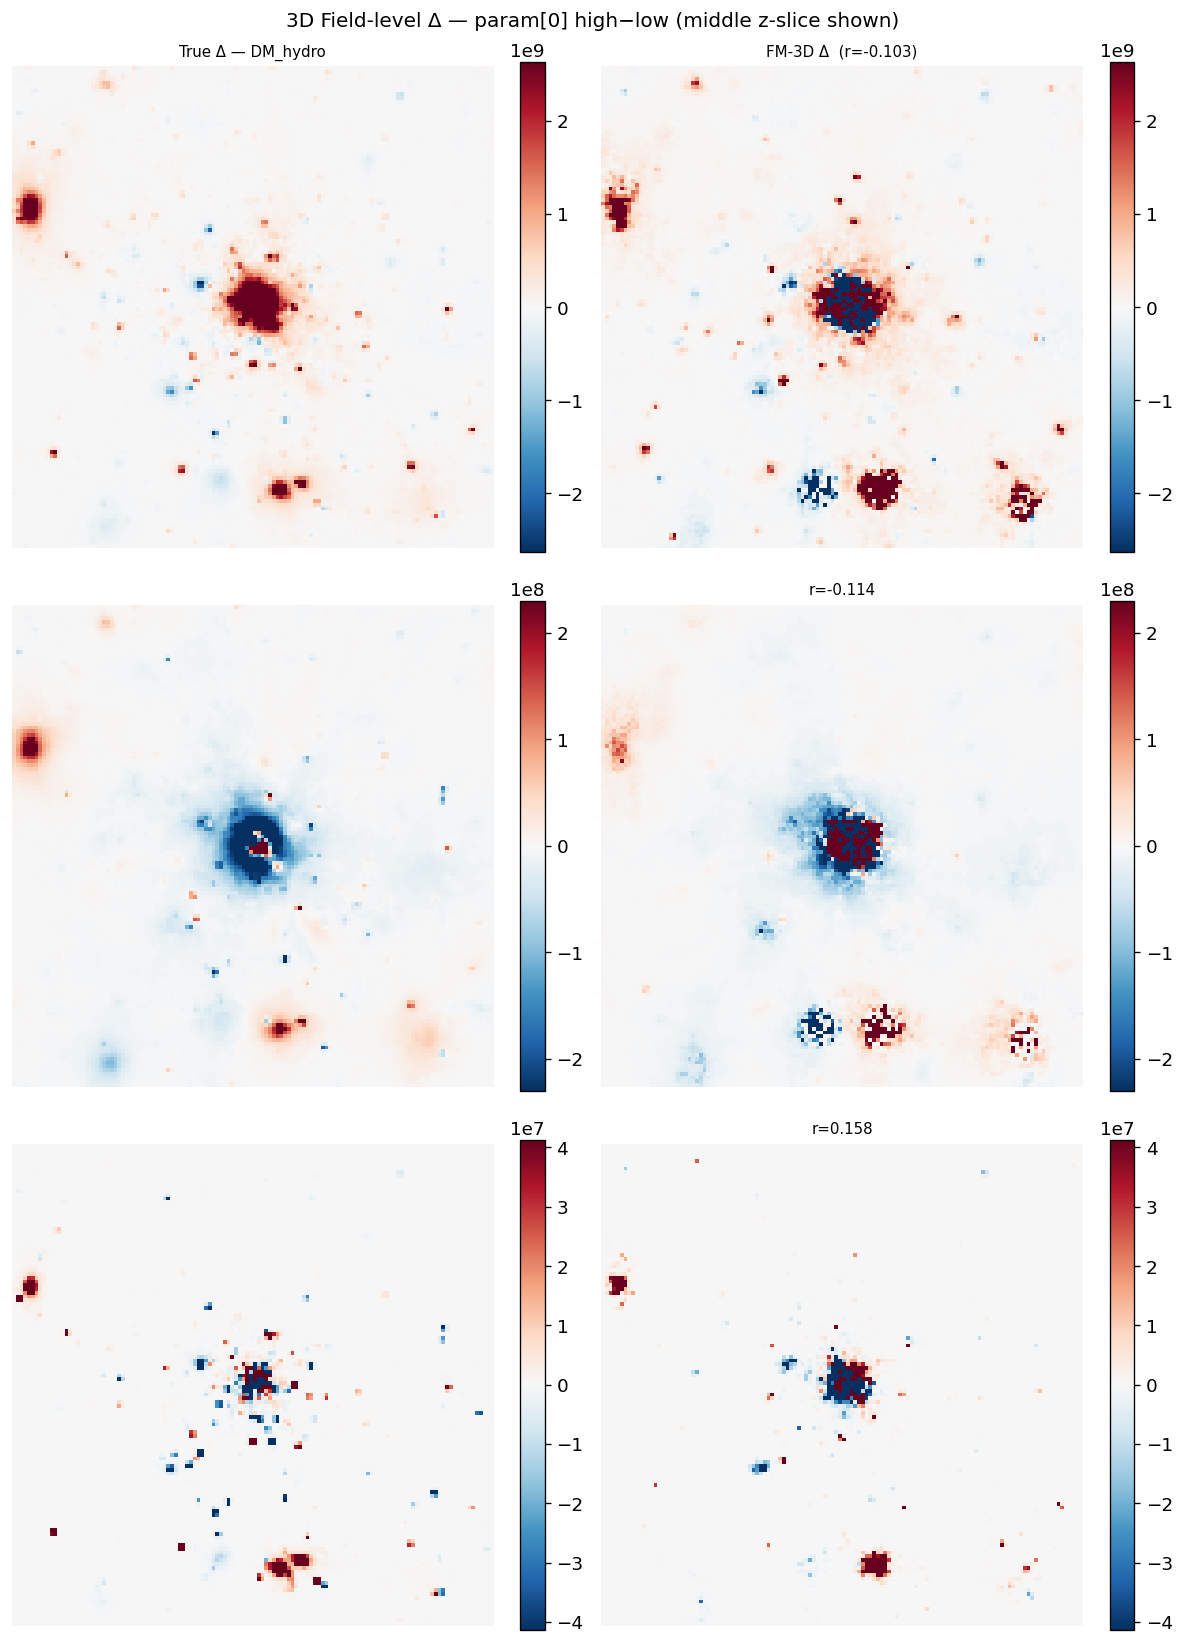

  3D correlation of Δ volumes with truth:
    DM_hydro     FM-3D: r3D = -0.0344
    Gas          FM-3D: r3D = 0.0041
    Stars        FM-3D: r3D = -0.0060

Param [1]  lo: 0.195  hi: 0.932  (50 volumes each)


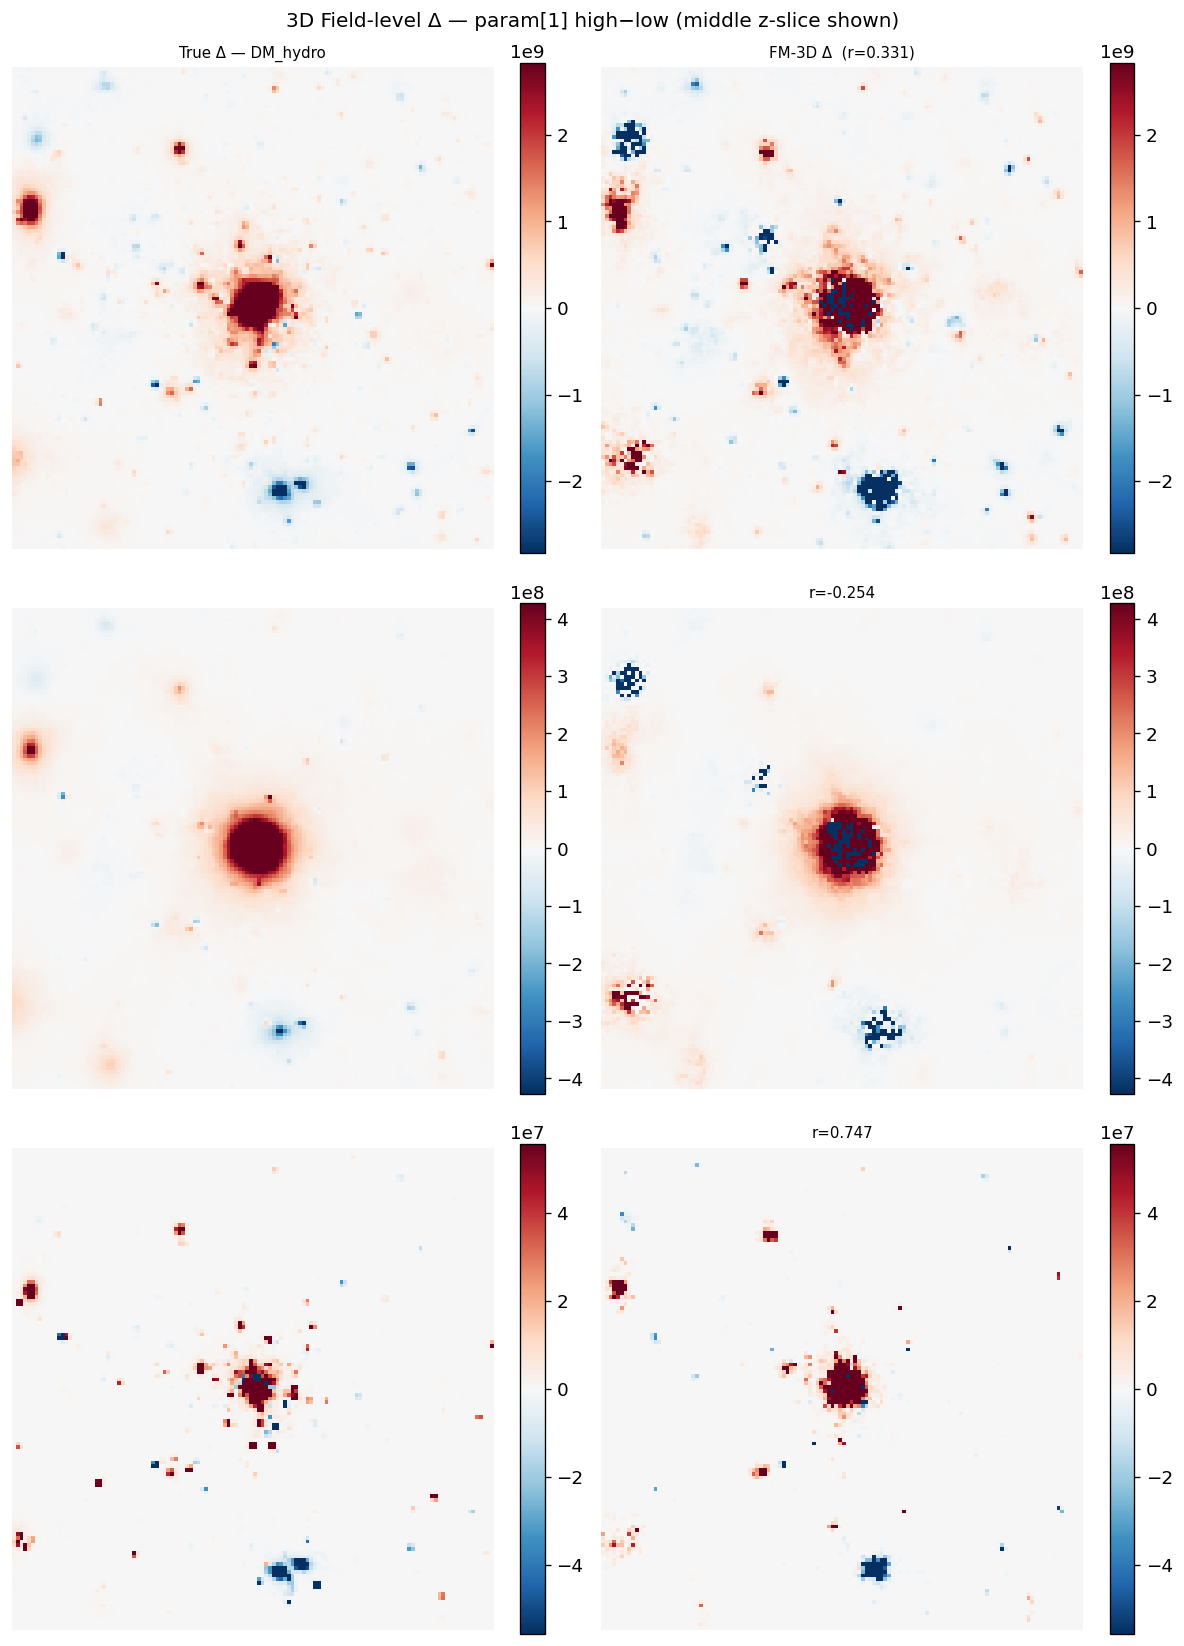

  3D correlation of Δ volumes with truth:
    DM_hydro     FM-3D: r3D = 0.0372
    Gas          FM-3D: r3D = 0.0024
    Stars        FM-3D: r3D = 0.5185


In [15]:
PARAM_AXES = [0, 1]
FRAC       = 0.25
N_Q        = max(5, int(len(real) * FRAC))   # ensure at least 5 volumes per group
SLICE_Z    = CROP_SIZE // 2

for p_idx in PARAM_AXES:
    p_vals = params[:, p_idx]
    order  = np.argsort(p_vals)
    lo_idx = order[:N_Q]
    hi_idx = order[-N_Q:]

    print(f'\nParam [{p_idx}]  lo: {p_vals[lo_idx].mean():.3f}  '
          f'hi: {p_vals[hi_idx].mean():.3f}  ({N_Q} volumes each)')

    n_models = len(results)
    fig, axes = plt.subplots(3, 1 + n_models, figsize=(5 * (1 + n_models), 14))

    for ch in range(3):
        # Middle slice of the mean difference volume
        delta_true = (real[hi_idx, ch].mean(0) - real[lo_idx, ch].mean(0))[SLICE_Z]
        vmax = np.percentile(np.abs(delta_true), 99)

        ax = axes[ch, 0]
        im = ax.imshow(delta_true, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
        ax.set_title(f'True Δ — {CHANNEL_NAMES[ch]}' if ch == 0 else '', fontsize=9)
        ax.set_ylabel(CHANNEL_NAMES[ch], fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

        for ri, (lbl, res) in enumerate(results.items()):
            delta_gen = (res['gen'][hi_idx, ch].mean(0) - res['gen'][lo_idx, ch].mean(0))[SLICE_Z]
            ax2 = axes[ch, ri + 1]
            im2 = ax2.imshow(delta_gen, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
            corr = np.corrcoef(delta_true.flatten(), delta_gen.flatten())[0, 1]
            ax2.set_title(f'{lbl} Δ  (r={corr:.3f})' if ch == 0 else f'r={corr:.3f}', fontsize=9)
            ax2.axis('off')
            plt.colorbar(im2, ax=ax2, fraction=0.046)

    plt.suptitle(f'3D Field-level Δ — param[{p_idx}] high−low (middle z-slice shown)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    # 3D correlation (not just a slice)
    print(f'  3D correlation of Δ volumes with truth:')
    for ch, name in enumerate(CHANNEL_NAMES):
        delta_true_3d = real[hi_idx, ch].mean(0) - real[lo_idx, ch].mean(0)
        for lbl, res in results.items():
            delta_gen_3d = res['gen'][hi_idx, ch].mean(0) - res['gen'][lo_idx, ch].mean(0)
            r3d = np.corrcoef(delta_true_3d.flatten(), delta_gen_3d.flatten())[0, 1]
            print(f'    {name:12s} {lbl}: r3D = {r3d:.4f}')

## 7. Numeric Summary


In [17]:
print('=' * 65)
print('NUMERIC SUMMARY — 3D model comparison')
print('=' * 65)

for lbl, res in results.items():
    gen = res['gen']
    print(f'\n── {lbl} ──')

    mass_errs, pk_errs, prof_errs = [], [], []
    for ch, name in enumerate(CHANNEL_NAMES):
        # Mass
        m_r = real[:, ch].sum(axis=(-3, -2, -1))
        m_g = gen[:,  ch].sum(axis=(-3, -2, -1))
        merr = float(np.median(np.abs((m_g - m_r) / (m_r + 1e-30))) * 100)
        mass_errs.append(merr)

        # P(k) on mean field
        k, pk_r = power_spectrum_3d(real[:, ch].mean(0), BOX_SIZE)
        _, pk_g = power_spectrum_3d(gen[:, ch].mean(0),  BOX_SIZE)
        mask = (k > 0) & (pk_r > 0)
        perr = float(np.median(np.abs(np.log10(pk_g[mask] / pk_r[mask] + 1e-10))))
        pk_errs.append(perr)

        # Radial profile error
        _, pr_m, _ = batch_profiles_3d(real[:, ch], n_bins=32)
        _, pg_m, _ = batch_profiles_3d(gen[:,  ch], n_bins=32)
        perrf = float(np.mean(np.abs(pg_m - pr_m) / (pr_m + 1e-8)))
        prof_errs.append(perrf)

        print(f'  {name:12s}  mass_err={merr:6.2f}%  '
              f'pk_log10_err={perr:.4f}  profile_relerr={perrf:.4f}')

    true_occ = (real[:, 2] > STAR_THRESH).mean() * 100
    gen_occ  = (gen[:,  2] > STAR_THRESH).mean() * 100
    print(f'  Stellar occupancy: true={true_occ:.2f}%  gen={gen_occ:.2f}%  '
          f'Δ={gen_occ - true_occ:+.2f} pp')
    print(f'  Mean mass err [%]: {np.mean(mass_errs):.2f}')
    print(f'  Mean P(k) err:     {np.mean(pk_errs):.4f}')

print('\n' + '=' * 65)

NUMERIC SUMMARY — 3D model comparison

── FM-3D ──
  DM_hydro      mass_err=29306.10%  pk_log10_err=10.2192  profile_relerr=1261.5127
  Gas           mass_err=196483250.00%  pk_log10_err=23.7691  profile_relerr=513482631.7301
  Stars         mass_err=304.83%  pk_log10_err=2.1045  profile_relerr=1.7843
  Stellar occupancy: true=0.48%  gen=45.24%  Δ=+44.76 pp
  Mean mass err [%]: 65504286.98
  Mean P(k) err:     12.0309

